数据读取完成


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



已保存图片: ../../results/04_asymmetric/Fig05_sunspot_dilution.eps
已保存图表数据: ../../results/04_asymmetric/Fig05_sunspot_dilution.xlsx


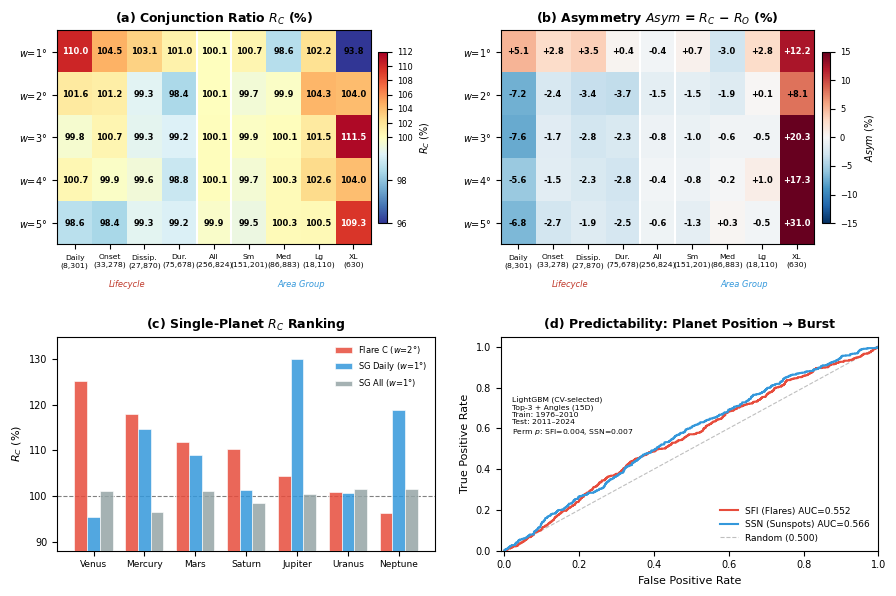

In [1]:
"""
Fig05 黑子群信号稀释 — V4 双热力图版
  (a) R_C 热力图：Lifecycle + Area × w=1~5
  (b) A = R_C - R_O 不对称度热力图
  (c) 单行星 R_C 排名对比
  (d) ROC 可预测性对比
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.transforms as mtransforms
import json, os

# ── 字体设置 ──
mpl.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'lines.linewidth': 1.2,
})

# ── 路径配置 ──
result_dir = '../../results/04_asymmetric'
sg_dir = os.path.join(result_dir, 'sg')
sf_dir = os.path.join(result_dir, 'sf')

COLOR_BASELINE = 'gray'

# ============================================================
# 数据读取
# ============================================================

algo1 = pd.read_csv(os.path.join(sg_dir, 'sg_algo1_total_pairs.csv'))

# --- 热力图数据：9 类别 × w=1~5, 分别取 R_C 和 R_O ---
categories_lifecycle = ['Daily', 'Onset', 'Dissipation', 'Duration']
area_groups_full = ['Small <100', 'Medium 100-500', 'Large 500-2000', 'XLarge >2000']
area_short_keys = ['Small', 'Medium', 'Large', 'XLarge']
display_labels = ['Daily', 'Onset', 'Dissip.', 'Dur.', 'All', 'Sm', 'Med', 'Lg', 'XL']
n_cats = len(display_labels)
windows = [1, 2, 3, 4, 5]

hm_rc = np.full((len(windows), n_cats), np.nan)  # R_C
hm_ro = np.full((len(windows), n_cats), np.nan)  # R_O
n_records = {}

# Lifecycle stages (cols 0-3)
for j, stage in enumerate(categories_lifecycle):
    for i, w in enumerate(windows):
        rc = algo1[(algo1['Stage'] == stage) & (algo1['Group'] == 'Total') &
                   (algo1['Window'] == w) & (algo1['Type'] == 'Conjunction')]
        ro = algo1[(algo1['Stage'] == stage) & (algo1['Group'] == 'Total') &
                   (algo1['Window'] == w) & (algo1['Type'] == 'Opposition')]
        if len(rc) > 0: hm_rc[i, j] = rc.iloc[0]['Ratio']
        if len(ro) > 0: hm_ro[i, j] = ro.iloc[0]['Ratio']
        if w == 1 and len(rc) > 0:
            n_records[stage] = int(rc.iloc[0]['N_Records'])

# All Total (col 4)
for i, w in enumerate(windows):
    rc = algo1[(algo1['Stage'] == 'All') & (algo1['Group'] == 'Total') &
               (algo1['Window'] == w) & (algo1['Type'] == 'Conjunction')]
    ro = algo1[(algo1['Stage'] == 'All') & (algo1['Group'] == 'Total') &
               (algo1['Window'] == w) & (algo1['Type'] == 'Opposition')]
    if len(rc) > 0: hm_rc[i, 4] = rc.iloc[0]['Ratio']
    if len(ro) > 0: hm_ro[i, 4] = ro.iloc[0]['Ratio']
    if w == 1 and len(rc) > 0:
        n_records['All'] = int(rc.iloc[0]['N_Records'])

# Area groups (cols 5-8)
for k, (grp, key) in enumerate(zip(area_groups_full, area_short_keys)):
    j = 5 + k
    for i, w in enumerate(windows):
        rc = algo1[(algo1['Stage'] == 'All') & (algo1['Group'] == grp) &
                   (algo1['Window'] == w) & (algo1['Type'] == 'Conjunction')]
        ro = algo1[(algo1['Stage'] == 'All') & (algo1['Group'] == grp) &
                   (algo1['Window'] == w) & (algo1['Type'] == 'Opposition')]
        if len(rc) > 0: hm_rc[i, j] = rc.iloc[0]['Ratio']
        if len(ro) > 0: hm_ro[i, j] = ro.iloc[0]['Ratio']
        if w == 1 and len(rc) > 0:
            n_records[key] = int(rc.iloc[0]['N_Records'])

# A = R_C - R_O
hm_a = hm_rc - hm_ro

# --- 单行星排名 ---
planet_masks = {1: 'Mercury', 2: 'Venus', 8: 'Mars',
                16: 'Jupiter', 32: 'Saturn', 64: 'Uranus', 128: 'Neptune'}

sf_cclass = pd.read_csv(os.path.join(sf_dir, 'sf_C_Class_subset_scan_no_earth.csv'))
flare_planet = sf_cclass[(sf_cclass['N_Planets'] == 1) &
                         (sf_cclass['Has_Earth'] == False) &
                         (sf_cclass['Window'] == 2)].copy()
flare_planet['Planet'] = flare_planet['Mask'].map(planet_masks)

sg_all = pd.read_csv(os.path.join(sg_dir, 'sg_subset_scan_no_earth.csv'))
sg_planet = sg_all[(sg_all['N_Planets'] == 1) & (sg_all['Has_Earth'] == False) &
                   (sg_all['Window'] == 1)].copy()
sg_planet['Planet'] = sg_planet['Mask'].map(planet_masks)

sg_daily_sub = pd.read_csv(os.path.join(sg_dir, 'sg_daily_subset_scan_no_earth.csv'))
sg_daily_planet = sg_daily_sub[(sg_daily_sub['N_Planets'] == 1) &
                               (sg_daily_sub['Has_Earth'] == False) &
                               (sg_daily_sub['Window'] == 1)].copy()
sg_daily_planet['Planet'] = sg_daily_planet['Mask'].map(planet_masks)

# --- ROC 数据 ---
roc_path = os.path.join(result_dir, '08_best_roc_data.json')
if not os.path.exists(roc_path):
    roc_path = os.path.join(result_dir, '00_exploratory/05_predictability_contrast/best_roc_data.json')
with open(roc_path) as f:
    roc_data = json.load(f)

print("数据读取完成")

# ============================================================
# 绘图：2 × 2
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# ── 共用函数：绘制热力图 ──
def draw_heatmap(ax, data, title, cmap_name, vmin, vmax, vcenter, cbar_label, fmt='{:.1f}'):
    cmap = mpl.colormaps[cmap_name]
    norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    im = ax.imshow(data, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

    for i in range(len(windows)):
        for j in range(n_cats):
            val = data[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val - vcenter) > (vmax - vcenter) * 0.7 else 'black'
                ax.text(j, i, fmt.format(val), ha='center', va='center',
                        fontsize=6, color=color, fontweight='bold')

    ax.set_xticks(np.arange(n_cats))
    ax.set_yticks(np.arange(len(windows)))
    ax.set_yticklabels([f'$w$={w}°' for w in windows], fontsize=7)
    ax.set_title(title)

    # 分隔线
    ax.axvline(x=3.5, color='white', linewidth=1.5)
    ax.axvline(x=4.5, color='white', linewidth=1.5)

    # x 轴标签：名称 + N
    key_map = {'Daily': 'Daily', 'Onset': 'Onset', 'Dissip.': 'Dissipation',
               'Dur.': 'Duration', 'All': 'All', 'Sm': 'Small', 'Med': 'Medium',
               'Lg': 'Large', 'XL': 'XLarge'}
    xtick_labels = []
    for lbl in display_labels:
        key = key_map.get(lbl, lbl)
        n = n_records.get(key, None)
        if n is not None:
            xtick_labels.append(f'{lbl}\n({n:,})')
        else:
            xtick_labels.append(lbl)
    ax.set_xticklabels(xtick_labels, fontsize=5.5)

    # 分组标注
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.5, -0.2, 'Lifecycle', transform=trans,
            fontsize=6, ha='center', color='#C0392B', fontstyle='italic')
    ax.text(6.5, -0.2, 'Area Group', transform=trans,
            fontsize=6, ha='center', color='#3498DB', fontstyle='italic')

    # colorbar
    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(cbar_label, fontsize=7)
    cbar.ax.tick_params(labelsize=6)
    return im

# ────────────────────────────────────────────────────────────
# (a) R_C 热力图
# ────────────────────────────────────────────────────────────
draw_heatmap(axes[0, 0], hm_rc,
             '(a) Conjunction Ratio $R_C$ (%)',
             'RdYlBu_r', 96, 112, 100, '$R_C$ (%)')

# ────────────────────────────────────────────────────────────
# (b) A = R_C - R_O 不对称度热力图
# ────────────────────────────────────────────────────────────
draw_heatmap(axes[0, 1], hm_a,
             '(b) Asymmetry $Asym$ = $R_C$ − $R_O$ (%)',
             'RdBu_r', -15, 15, 0, '$Asym$ (%)',
             fmt='{:+.1f}')

# ────────────────────────────────────────────────────────────
# (c) 单行星 R_C 排名
# ────────────────────────────────────────────────────────────
ax = axes[1, 0]

flare_sorted = flare_planet.sort_values('Conj_Ratio', ascending=False)
planet_order = flare_sorted['Planet'].tolist()

sg_dict = dict(zip(sg_planet['Planet'], sg_planet['Conj_Ratio']))
sg_daily_dict = dict(zip(sg_daily_planet['Planet'], sg_daily_planet['Conj_Ratio']))

x = np.arange(len(planet_order))
bar_width = 0.25

bars1 = ax.bar(x - bar_width, [flare_sorted[flare_sorted['Planet']==p]['Conj_Ratio'].values[0]
                                for p in planet_order],
               bar_width, color='#E74C3C', alpha=0.85, label='Flare C ($w$=2°)',
               edgecolor='white', linewidth=0.5, zorder=3)
bars2 = ax.bar(x, [sg_daily_dict.get(p, 100) for p in planet_order],
               bar_width, color='#3498DB', alpha=0.85, label='SG Daily ($w$=1°)',
               edgecolor='white', linewidth=0.5, zorder=3)
bars3 = ax.bar(x + bar_width, [sg_dict.get(p, 100) for p in planet_order],
               bar_width, color='#95A5A6', alpha=0.85, label='SG All ($w$=1°)',
               edgecolor='white', linewidth=0.5, zorder=3)

ax.axhline(y=100, color=COLOR_BASELINE, linewidth=0.8, linestyle='--', zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(planet_order, fontsize=6.5)
ax.set_ylabel('$R_C$ (%)')
ax.set_ylim(88, 135)
ax.set_title('(c) Single-Planet $R_C$ Ranking')
ax.legend(loc='upper right', framealpha=0.9, edgecolor='none', fontsize=6)

# ────────────────────────────────────────────────────────────
# (d) ROC 可预测性对比
# ────────────────────────────────────────────────────────────
ax = axes[1, 1]

roc_cfg = roc_data['roc']
fpr_sfi = np.array(roc_cfg['sfi']['fpr'])
tpr_sfi = np.array(roc_cfg['sfi']['tpr'])
auc_sfi = roc_cfg['sfi']['auc']

fpr_ssn = np.array(roc_cfg['ssn']['fpr'])
tpr_ssn = np.array(roc_cfg['ssn']['tpr'])
auc_ssn = roc_cfg['ssn']['auc']

# 从 JSON 读取置换检验 p 值
perm_info = roc_data.get('permutation', {})
p_sfi = perm_info.get('sfi', {}).get('p', None)
p_ssn = perm_info.get('ssn', {}).get('p', None)

ax.plot(fpr_sfi, tpr_sfi, color='#E74C3C', linewidth=1.5,
        label=f'SFI (Flares) AUC={auc_sfi:.3f}', zorder=4)
ax.plot(fpr_ssn, tpr_ssn, color='#3498DB', linewidth=1.5,
        label=f'SSN (Sunspots) AUC={auc_ssn:.3f}', zorder=4)
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=0.8, alpha=0.5,
        label='Random (0.500)', zorder=2)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_title('(d) Predictability: Planet Position → Burst')
ax.legend(loc='lower right', framealpha=0.9, edgecolor='none', fontsize=6.5)

# 动态构建注释文字
perm_line = ''
if p_sfi is not None and p_ssn is not None:
    perm_line = f'\nPerm $p$: SFI={p_sfi:.3f}, SSN={p_ssn:.3f}'
elif p_sfi is not None:
    perm_line = f'\nPerm $p$ = {p_sfi:.3f}'

ax.text(0.03, 0.72, f'LightGBM (CV-selected)\nTop-3 + Angles (15D)\nTrain: 1976–2010\nTest: 2011–2024{perm_line}',
        transform=ax.transAxes, fontsize=5.5, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout(w_pad=2.0, h_pad=2.5)

# ============================================================
# 保存
# ============================================================
out_name = 'Fig05_sunspot_dilution'
eps_path = os.path.join(result_dir, f'{out_name}.eps')
fig.savefig(eps_path, format='eps', dpi=300, bbox_inches='tight')
print(f"\n已保存图片: {eps_path}")

# plt.show()

# ============================================================
# 保存图表背后的数据 (推荐使用 Excel 多 Sheet 格式)
# ============================================================
excel_path = os.path.join(result_dir, f'{out_name}.xlsx')

# 1. 整理 (a) 和 (b) 的热力图数据
df_hm_rc = pd.DataFrame(hm_rc, index=[f'w={w}°' for w in windows], columns=display_labels)
df_hm_a = pd.DataFrame(hm_a, index=[f'w={w}°' for w in windows], columns=display_labels)

# 2. 整理 (c) 单行星排名的柱状图数据
df_ranking = pd.DataFrame({
    'Planet': planet_order,
    'Flare_C (w=2)': [flare_sorted[flare_sorted['Planet']==p]['Conj_Ratio'].values[0] for p in planet_order],
    'SG_Daily (w=1)': [sg_daily_dict.get(p, 100) for p in planet_order],
    'SG_All (w=1)': [sg_dict.get(p, 100) for p in planet_order]
})

# 3. 整理 (d) ROC 曲线数据
df_roc = pd.concat([
    pd.Series(fpr_sfi, name='FPR_SFI'),
    pd.Series(tpr_sfi, name='TPR_SFI'),
    pd.Series(fpr_ssn, name='FPR_SSN'),
    pd.Series(tpr_ssn, name='TPR_SSN')
], axis=1)

# 4. 写入同一个 Excel 文件的不同 Sheet 中
try:
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        df_hm_rc.to_excel(writer, sheet_name='(a) RC_Heatmap')
        df_hm_a.to_excel(writer, sheet_name='(b) A_Heatmap')
        df_ranking.to_excel(writer, sheet_name='(c) Planet_Ranking', index=False)
        df_roc.to_excel(writer, sheet_name='(d) ROC_Curves', index=False)
    print(f"已保存图表数据: {excel_path}")
except ModuleNotFoundError:
    print("保存 Excel 失败: 缺少 openpyxl 库。请在终端运行 `pip install openpyxl` 后重试。")